# Evaluating QD probabilty of detection given some of its property

**Please, use venv-ml to run this file.**

Select top 5 algorithms to be working with based on their F1 scores. Loss function for the new model will be getting trained on them.

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()

while not (
    (PROJECT_ROOT / "Detection").exists()
    and (PROJECT_ROOT / "Image-Preprocessing").exists()
    and (PROJECT_ROOT / "Ground-Truth").exists()
    and (PROJECT_ROOT / "QD-Analysis").exists()
):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

DETECTION_DIR = PROJECT_ROOT / "Detection"
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"
GROUND_TRUTH_DIR = PROJECT_ROOT / "Ground-Truth"
QD_ANALYSIS_DIR = PROJECT_ROOT / "QD-Analysis"
CLASSICAL_DIR = DETECTION_DIR / "Classical-Optimised"
BIOLOGY_DIR = DETECTION_DIR / "Biology-Inspired"
CNN_DIR = DETECTION_DIR / "Binary-Unet"

for path in [PROJECT_ROOT, DETECTION_DIR, PREPROCESSING_DIR, GROUND_TRUTH_DIR, QD_ANALYSIS_DIR, CLASSICAL_DIR, BIOLOGY_DIR, CNN_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import QD_analysis as qa
importlib.reload(qa)

top5 = ["U-Net", "Watershed", "Chambolle", "Otsu", "LoG"]

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd

from scipy.ndimage import binary_dilation
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from skimage.measure import label, regionprops

import QD_analysis as qa


PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import preprocessing_metrics as pm

import detection_algorithms as da
import detection_errors as de

import QD_analysis as qa

import feature_evaluation as fe

## Upload the data and pre-process the scans

In [3]:
# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)

# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)

# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)

# RUN CLASSICAL ALGORITHMS
algorithm_results = {}
algorithm_results["log"] = da.log_detect(image, image_preprocessed)
algorithm_results["chambolle"] = da.chambolle_anisotropic_diffusion_detect(image, image_preprocessed)
algorithm_results["otsu"] = da.otsu_detect(image, image_preprocessed)
algorithm_results["watershed"] = da.watershed_detect(image, image_preprocessed)

# LOAD U-NET
model = tf.keras.models.load_model(PROJECT_ROOT / "Detection/Binary-Unet/qd_unet_fold1.keras", compile=False)

In [4]:
qd_df = qa.extract_qd_features(image_preprocessed, Y_test)
qd_df["height_nm"] = qd_df["height"] * 1e9

qd_df = qa.extract_qd_features(image_preprocessed, Y_test)
qd_df["height_nm"] = qd_df["height"] * 1e9

for algorithm_name, result in algorithm_results.items():
    safe = algorithm_name.lower().replace(" ", "_").replace("-", "_")
    centres = result["after_height_filter"]["centres"]

    detected, distance = qa.match_detections(qd_df, centres, tolerance=3.0)

    qd_df[f"{safe}_after"] = detected
    qd_df[f"{safe}_after_distance"] = distance

Attach each algorithm's detected/missed state to every GT QD:

In [5]:
prediction = fe.predict_full_scan(model, X_test, patch_size=128)

unet_mask = prediction >= 0.5
unet_centres = qa.centres_from_binary_mask(unet_mask)

detected, distance = qa.match_detections(qd_df, unet_centres, tolerance=3.0)

qd_df["unet_after"] = detected
qd_df["unet_after_distance"] = distance

print("U-Net predicted QDs:", len(unet_centres))
print("GT QDs detected by U-Net:", detected.sum())

U-Net predicted QDs: 126
GT QDs detected by U-Net: 105


## Probability of detecting a dot given its height 

In [6]:
print(qd_df.columns.tolist())

['qd_id', 'cy', 'cx', 'height', 'area', 'radius', 'local_contrast', 'local_background_std', 'local_background_mad', 'nearest_qd_distance', 'edge_distance', 'height_nm', 'log_after', 'log_after_distance', 'chambolle_after', 'chambolle_after_distance', 'otsu_after', 'otsu_after_distance', 'watershed_after', 'watershed_after_distance', 'unet_after', 'unet_after_distance']


In [7]:
import QD_analysis as qa
import importlib
importlib.reload(qa)

log_height_probability = qa.detection_probability_by_feature(
    qd_df,
    algorithm="LoG",
    feature="height",
)

display(log_height_probability)

,bin,probability,n,feature_mean,feature_median
0,"(-0.001000000185, 8.38e-10]",0.260870,23,6.473111e-10,6.981184e-10
1,"(8.38e-10, 1.07e-09]",0.727273,22,9.665386e-10,9.909398e-10
2,"(1.07e-09, 1.28e-09]",0.782609,23,1.165722e-09,1.158968e-09
3,"(1.28e-09, 1.49e-09]",0.727273,22,1.387709e-09,1.384506e-09
4,"(1.49e-09, 1.71e-09]",0.818182,22,1.621492e-09,1.621352e-09
5,"(1.71e-09, 2.65e-09]",0.782609,23,2.069865e-09,2.067678e-09


In [8]:
for algorithm_name, result in algorithm_results.items():
    safe_name = algorithm_name.lower().replace(" ", "_").replace("-", "_")

    centres = result["after_height_filter"]["centres"]
    detected, distance = qa.match_detections(qd_df, centres, tolerance=3.0)

    qd_df[f"{safe_name}_after"] = detected
    qd_df[f"{safe_name}_after_distance"] = distance

print([c for c in qd_df.columns if c.endswith("_after")])

['log_after', 'chambolle_after', 'otsu_after', 'watershed_after', 'unet_after']


### Plotting probability of detecting a dot given its height continuously (involves interpolation)

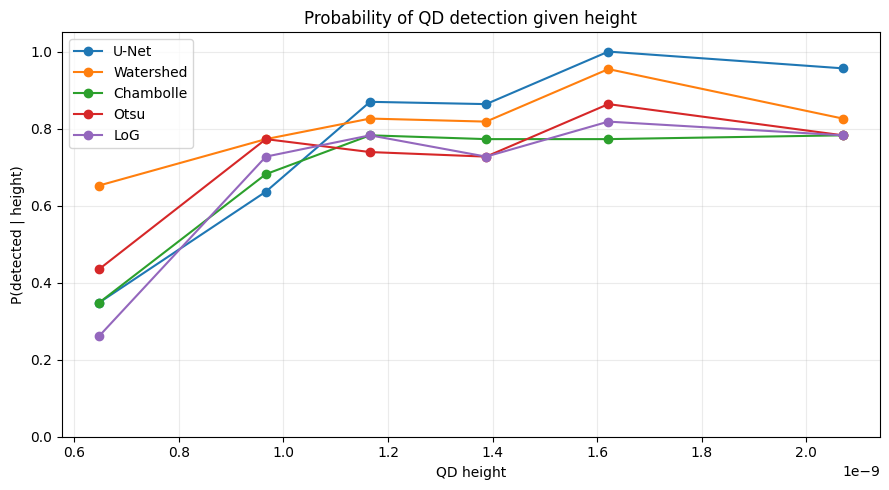

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for algorithm in top5:
    result = qa.detection_probability_by_feature(
        qd_df,
        algorithm,
        "height",
        n_bins=6,
    )

    ax.plot(
        result["feature_mean"],
        result["probability"],
        marker="o",
        label=algorithm,
    )

ax.set_ylim(0, 1.05)
ax.set_xlabel("QD height")
ax.set_ylabel("P(detected | height)")
ax.set_title("Probability of QD detection given height")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Probability of detecting a dot given its local contrast 

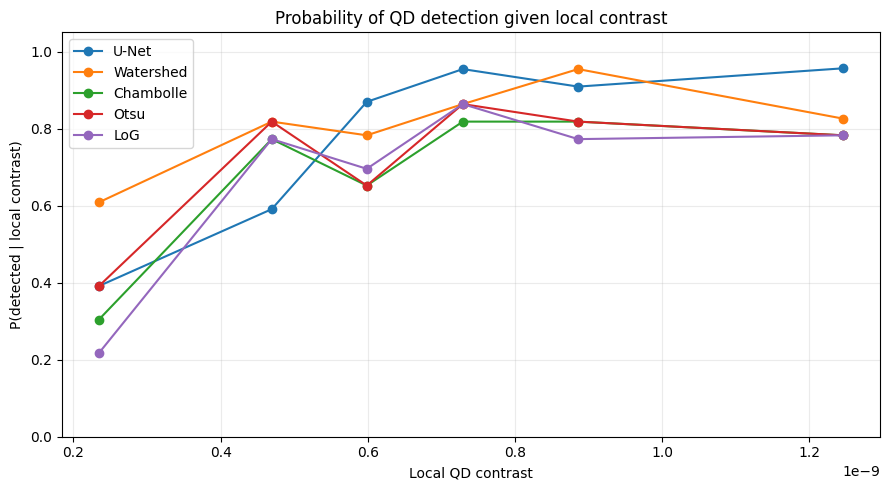

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for algorithm in top5:
    result = qa.detection_probability_by_feature(
        qd_df,
        algorithm,
        "local_contrast",
        n_bins=6,
    )

    ax.plot(
        result["feature_mean"],
        result["probability"],
        marker="o",
        label=algorithm,
    )

ax.set_ylim(0, 1.05)
ax.set_xlabel("Local QD contrast")
ax.set_ylabel("P(detected | local contrast)")
ax.set_title("Probability of QD detection given local contrast")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Probability of detecting a dot given its position:  On-pit vs Off-pit

In [12]:
import importlib
import QD_analysis as qa
importlib.reload(qa)

GaN_mask = qa.create_gan_mask(image_preprocessed)
qd_df = qa.add_pit_status(qd_df, Y_test, GaN_mask, overlap_threshold=0.5)
print(qd_df["on_pit"].value_counts())

on_pit
True     130
False      5
Name: count, dtype: int64


,algorithm,location,probability,n
0,U-Net,Off pit,0.600000,5
1,U-Net,On pit,0.784615,130
2,Watershed,Off pit,0.800000,5
3,Watershed,On pit,0.807692,130
4,Chambolle,Off pit,0.400000,5
5,Chambolle,On pit,0.700000,130
6,Otsu,Off pit,0.600000,5
7,Otsu,On pit,0.723077,130
8,LoG,Off pit,0.400000,5
9,LoG,On pit,0.692308,130


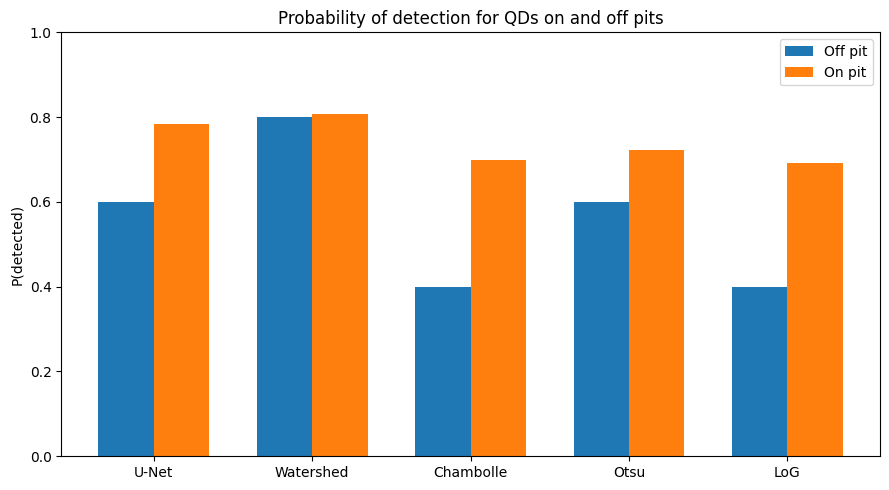

In [13]:
pit_probability_df = qa.detection_probability_by_pit(
    qd_df,
    top5,
)

display(pit_probability_df)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(top5))
width = 0.35

off_pit = (
        pit_probability_df[
        pit_probability_df["location"] == "Off pit"
    ]
    .set_index("algorithm")
    .loc[top5]
)

on_pit = (
    pit_probability_df[
        pit_probability_df["location"] == "On pit"
    ]
    .set_index("algorithm")
    .loc[top5]
)

ax.bar(x - width/2, off_pit["probability"], width, label="Off pit")
ax.bar(x + width/2, on_pit["probability"], width, label="On pit")

ax.set_xticks(x)
ax.set_xticklabels(top5)
ax.set_ylim(0, 1)
ax.set_ylabel("P(detected)")
ax.set_title("Probability of detection for QDs on and off pits")
ax.legend()

plt.tight_layout()
plt.show()

## Multivariable detection probability

In [14]:
unet_probability_model = qa.fit_multivariable_detection_model(
    qd_df,
    "U-Net",
)

## Complementary probabilities 

In [ ]:
for algorithm in top5:
    if algorithm == "U-Net":
        continue

    p = qa.probability_detected_given_missed(
        qd_df,
        detector=algorithm,
        missed_by="U-Net",
    )

    print(f"P({algorithm} detects | U-Net misses) = {p:.3f}")

P(Watershed detects | U-Net misses) = 0.500
P(Chambolle detects | U-Net misses) = 0.433
P(Otsu detects | U-Net misses) = 0.433
P(LoG detects | U-Net misses) = 0.333


In [16]:
rescue_matrix = qa.build_rescue_matrix(
    qd_df,
    top5,
)

display(rescue_matrix)

,U-Net,Watershed,Chambolle,Otsu,LoG
U-Net,0.000000,0.423077,0.595238,0.552632,0.534884
Watershed,0.500000,0.000000,0.476190,0.421053,0.511628
Chambolle,0.433333,0.153846,0.000000,0.052632,0.116279
Otsu,0.433333,0.153846,0.142857,0.000000,0.186047
LoG,0.333333,0.192308,0.095238,0.078947,0.000000


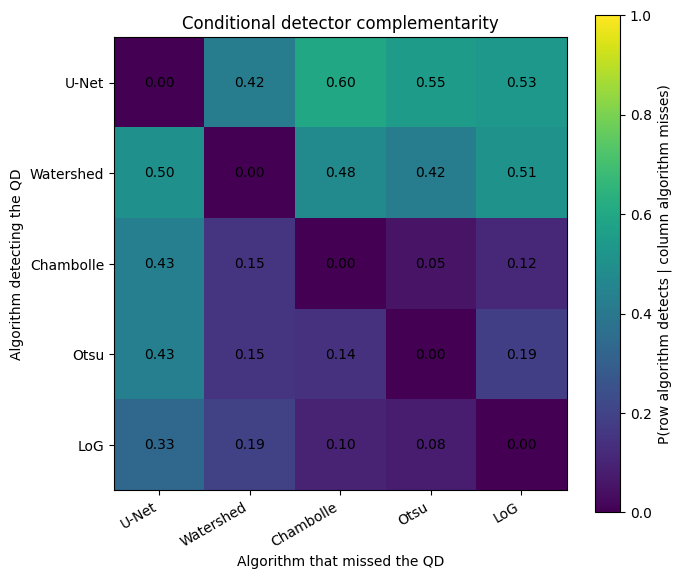

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    rescue_matrix,
    vmin=0,
    vmax=1,
    cmap="viridis",
)

ax.set_xticks(np.arange(len(top5)))
ax.set_xticklabels(top5, rotation=30, ha="right")

ax.set_yticks(np.arange(len(top5)))
ax.set_yticklabels(top5)

for i in range(len(top5)):
    for j in range(len(top5)):
        value = rescue_matrix.iloc[i, j]

        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
            )

ax.set_xlabel("Algorithm that missed the QD")
ax.set_ylabel("Algorithm detecting the QD")
ax.set_title("Conditional detector complementarity")

fig.colorbar(
    im,
    ax=ax,
    label="P(row algorithm detects | column algorithm misses)",
)

plt.tight_layout()
plt.show()

In [19]:
algorithm_columns = {
    "U-Net": "unet_after",
    "Watershed": "watershed_after",
    "Chambolle": "chambolle_after",
    "Otsu": "otsu_after",
    "LoG": "log_after",
}

unet_missed_on_pit = qd_df[(~qd_df["unet_after"]) & qd_df["on_pit"]]

for algorithm in top5:
    if algorithm == "U-Net":
        continue

    col = algorithm_columns[algorithm]
    print(algorithm, unet_missed_on_pit[col].mean())

Watershed 0.5
Chambolle 0.4642857142857143
Otsu 0.42857142857142855
LoG 0.35714285714285715


# Random Forest

Creates a tree based on the conditional probabilities above. Can then predict whether something is a dot or not. 

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

detector_features = [
    "watershed_after",
    "chambolle_after",
    "otsu_after",
    "log_after",
]

features = [
    "height_nm",
    "radius",
    "area",
    "local_contrast",
    "local_background_std",
    "local_background_mad",
    "nearest_qd_distance",
    "edge_distance",
    "on_pit",
] + detector_features

data = qd_df[features + ["unet_after"]].dropna().copy()

X = data[features]
y = data["unet_after"].astype(int)

X_train, X_test_rf, y_train, y_test_rf = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test_rf)
y_prob = rf.predict_proba(X_test_rf)[:, 1]

print(classification_report(y_test_rf, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_rf, y_prob))

              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.88      0.85      0.86        26

    accuracy                           0.79        34
   macro avg       0.72      0.74      0.73        34
weighted avg       0.80      0.79      0.80        34

ROC-AUC: 0.8413461538461537


In [21]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
display(importance)

height_nm               0.286429
local_contrast          0.256158
local_background_std    0.100522
nearest_qd_distance     0.098925
area                    0.070415
radius                  0.064298
local_background_mad    0.061796
edge_distance           0.061456
on_pit                  0.000000
dtype: float64

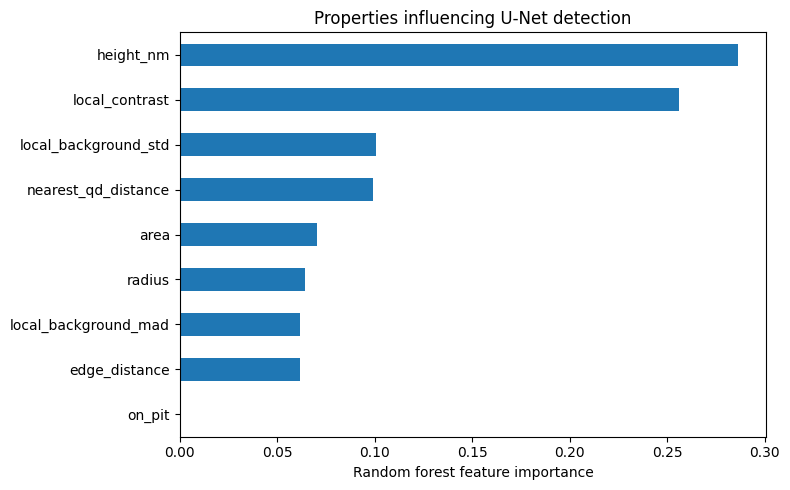

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
importance.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Random forest feature importance")
ax.set_title("Properties influencing U-Net detection")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

features = [
    "height_nm",
    "radius",
    "area",
    "local_contrast",
    "local_background_std",
    "local_background_mad",
    "nearest_qd_distance",
    "edge_distance",
    "on_pit",
]

X = qd_df[features]
y = qd_df["unet_after"].astype(int)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    class_weight="balanced",
    random_state=42,
)

rf.fit(X, y)

,n_estimators,500
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
new_qd = pd.DataFrame([{
    "height_nm": 0.8,
    "radius": 4.2,
    "area": 55,
    "local_contrast": 4e-10,
    "local_background_std": 2e-10,
    "local_background_mad": 1.5e-10,
    "nearest_qd_distance": 18,
    "edge_distance": 100,
    "on_pit": True,
}])

rf.predict(new_qd)

# probability of missing a dot, vs probability of predicting a dot 
rf.predict_proba(new_qd)

array([[0.25403334, 0.74596666]])